In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

import itertools
import warnings

In [159]:
df = pd.read_csv('D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\oil.csv')
df 

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


In [160]:
df.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [161]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


In [162]:
df.set_index('date', inplace=True)

In [163]:
df['dcoilwtico'] = df['dcoilwtico'].interpolate()

In [164]:
df_monthly = df.resample('M').mean()

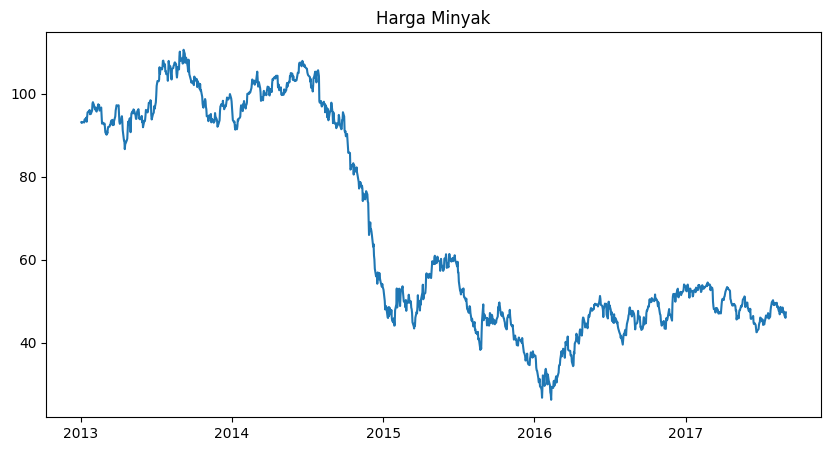

In [165]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['dcoilwtico'])
plt.title("Harga Minyak")
plt.show()

In [166]:
df.isnull().sum()

dcoilwtico    1
dtype: int64

In [167]:
train_prophet = df_prophet.iloc[:len(train)]
test_prophet  = df_prophet.iloc[len(train):]

In [168]:
result = adfuller(train['dcoilwtico'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -0.9887325907299441
p-value: 0.7573516142300358


In [169]:
train_diff1 = train['dcoilwtico'].diff().dropna()

In [170]:
result = adfuller(train_diff1)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -4.005220693036453
p-value: 0.0013834195406823599


In [171]:
df_prophet = df_monthly.reset_index()
df_prophet.columns = ['ds', 'y']

In [172]:
df_prophet['y'] = np.log(df_prophet['y'])

In [173]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,   # default 0.05 → lebih fleksibel
    seasonality_prior_scale=10
)

model.fit(train_prophet)

18:41:04 - cmdstanpy - INFO - Chain [1] start processing
18:41:35 - cmdstanpy - INFO - Chain [1] done processing


In [174]:
future = model.make_future_dataframe(
    periods=len(test),
    freq='M'
)

forecast = model.predict(future)

In [175]:
forecast_test = forecast.iloc[-len(test):]['yhat'].values

In [176]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100
rmse = np.sqrt(mean_squared_error(test_prophet['y'], forecast_test))
mae = mean_absolute_error(test_prophet['y'], forecast_test)

print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape(test_prophet['y'], forecast_test))

RMSE: 0.42580033189681915
MAE : 0.35200181864244434
MAPE: 8.974188172563009


Text(0.5, 1.0, 'Prophet Forecast vs Actual')

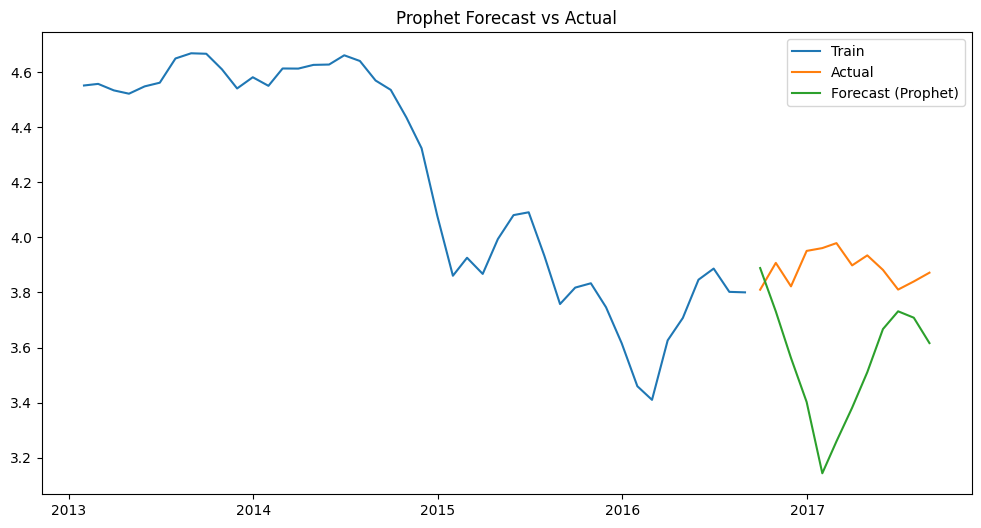

In [177]:
plt.figure(figsize=(12,6))

plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual')
plt.plot(test_prophet['ds'], forecast_test, label='Forecast (Prophet)')

plt.legend()
plt.title('Prophet Forecast vs Actual')

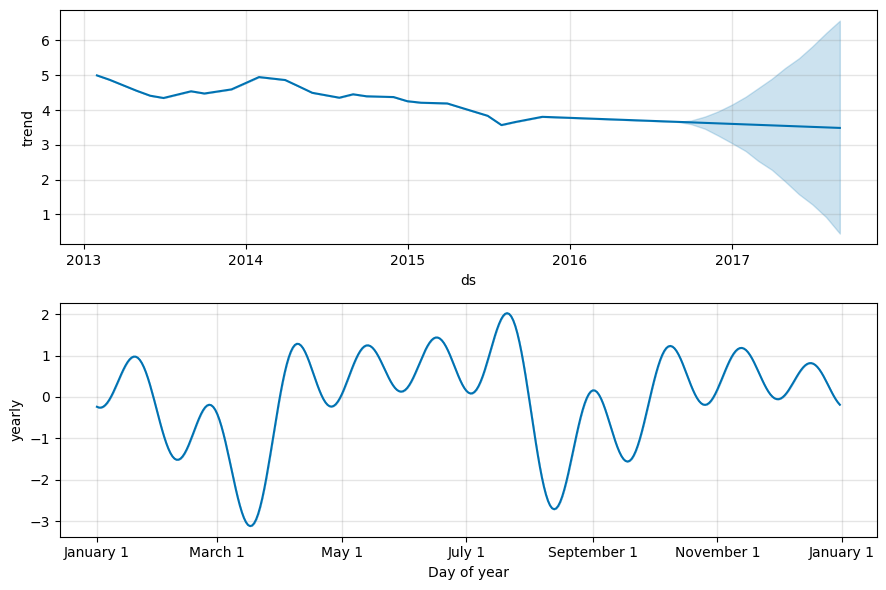

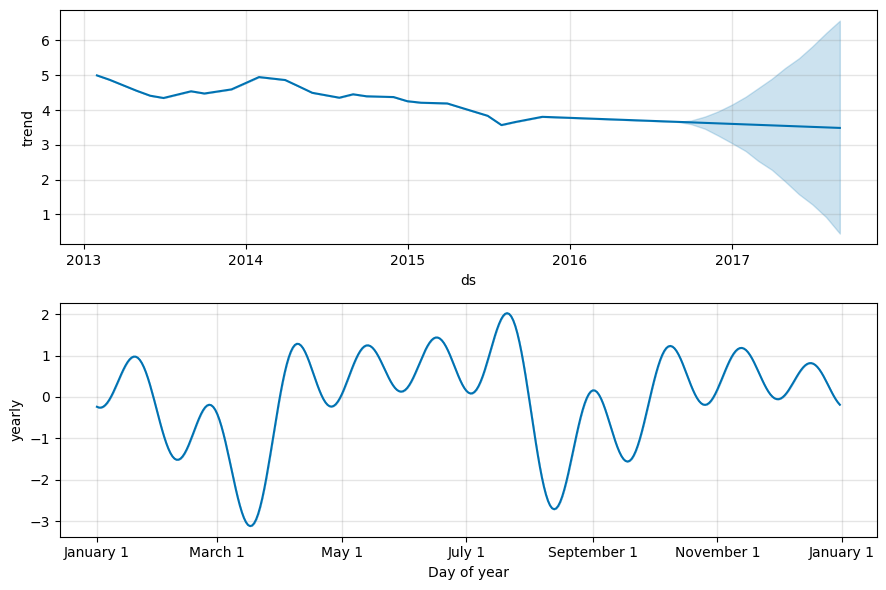

In [178]:
model.plot_components(forecast)